# Sweep vs $L$ — observables & transition
$h_z \\in [0.15, 0.50]$, $L = 6,8,10,12$. Diverged runs skipped.

In [26]:
import json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
NQS, ED = Path("../results/nqs"), Path("../results/ed")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)          # high-res outputs land here

In [27]:
def load(L, hz):
    d = json.load(open(NQS / f"G-equiv_1_L{L}_hx0.00_hz{hz:.3f}.json"))
    E = np.array([complex(x).real for x in d["energy"]])
    V = np.array([complex(x).real for x in d["Vscore"]])
    return d, E, V

def sweep(L):                                   # {hz: data} for finite (non-diverged) runs
    out = {}
    for p in sorted(NQS.glob(f"G-equiv_1_L{L}_hx0.00_hz*.json")):
        hz = float(re.search(r"hz([\d.]+)\.json", p.name).group(1))
        d, E, _ = load(L, hz)
        if np.isfinite(E[-1]):
            out[hz] = d
    return out

Ls = [6, 8, 10, 12]
data = {L: sweep(L) for L in Ls}
cols = dict(zip(Ls, plt.cm.plasma(np.linspace(0, 0.85, len(Ls)))))

_wil = lambda d: d["order_params"]["WilsonBFFM"][-1] if d["order_params"]["WilsonBFFM"] else None
mag_z    = lambda d: np.mean(d["order_params"]["magnetization_Zmean"][-1])
wilson_x = lambda d: _wil(d)[0] if _wil(d) else np.nan      # closed sigma^x loop
bffm_z   = lambda d: _wil(d)[6] if _wil(d) else np.nan      # <open sigma^z> / sqrt(<closed sigma^z>)
renyi2   = lambda d: d["order_params"]["renyi2_entropy"][-1][0] if d["order_params"]["renyi2_entropy"] else np.nan

def curve(L, fn):                               # (hz array, observable array) for one L
    hz = np.array(sorted(data[L]))
    return hz, np.array([fn(data[L][h]) for h in hz])

def plot_vs_hz(ax, fn, ylabel):
    for L in Ls:
        hz, y = curve(L, fn)
        ax.plot(hz, y, "o-", color=cols[L], ms=4, lw=1.2, label=f"L={L}")
    ax.set(xlabel="$h_z$", ylabel=ylabel)

AttributeError: 'NoneType' object has no attribute 'group'

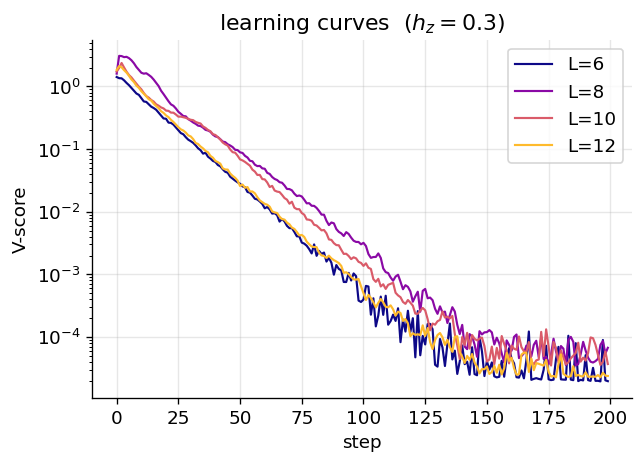

In [28]:
HZ = 0.30
fig, ax = plt.subplots(figsize=(5.5, 4))
for L in Ls:
    _, _, V = load(L, HZ)
    ax.plot(np.arange(len(V)), V, color=cols[L], lw=1.3, label=f"L={L}")
ax.set(xlabel="step", ylabel="V-score", yscale="log", title=f"learning curves  ($h_z={HZ}$)")
ax.legend()
fig.tight_layout()
# fig.savefig(FIG / "learning_curves_vs_L.png", dpi=300, bbox_inches="tight")

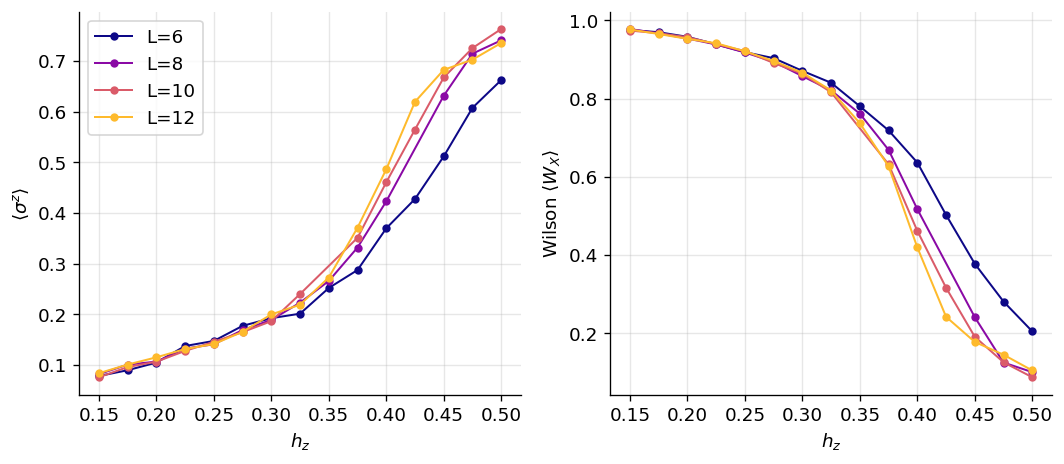

In [29]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
plot_vs_hz(a1, mag_z,    r"$\langle\sigma^z\rangle$")
plot_vs_hz(a2, wilson_x, r"Wilson $\langle W_X\rangle$")
a1.legend()
fig.tight_layout()
fig.savefig(FIG / "obs_params_vs_hz.png", dpi=300, bbox_inches="tight")

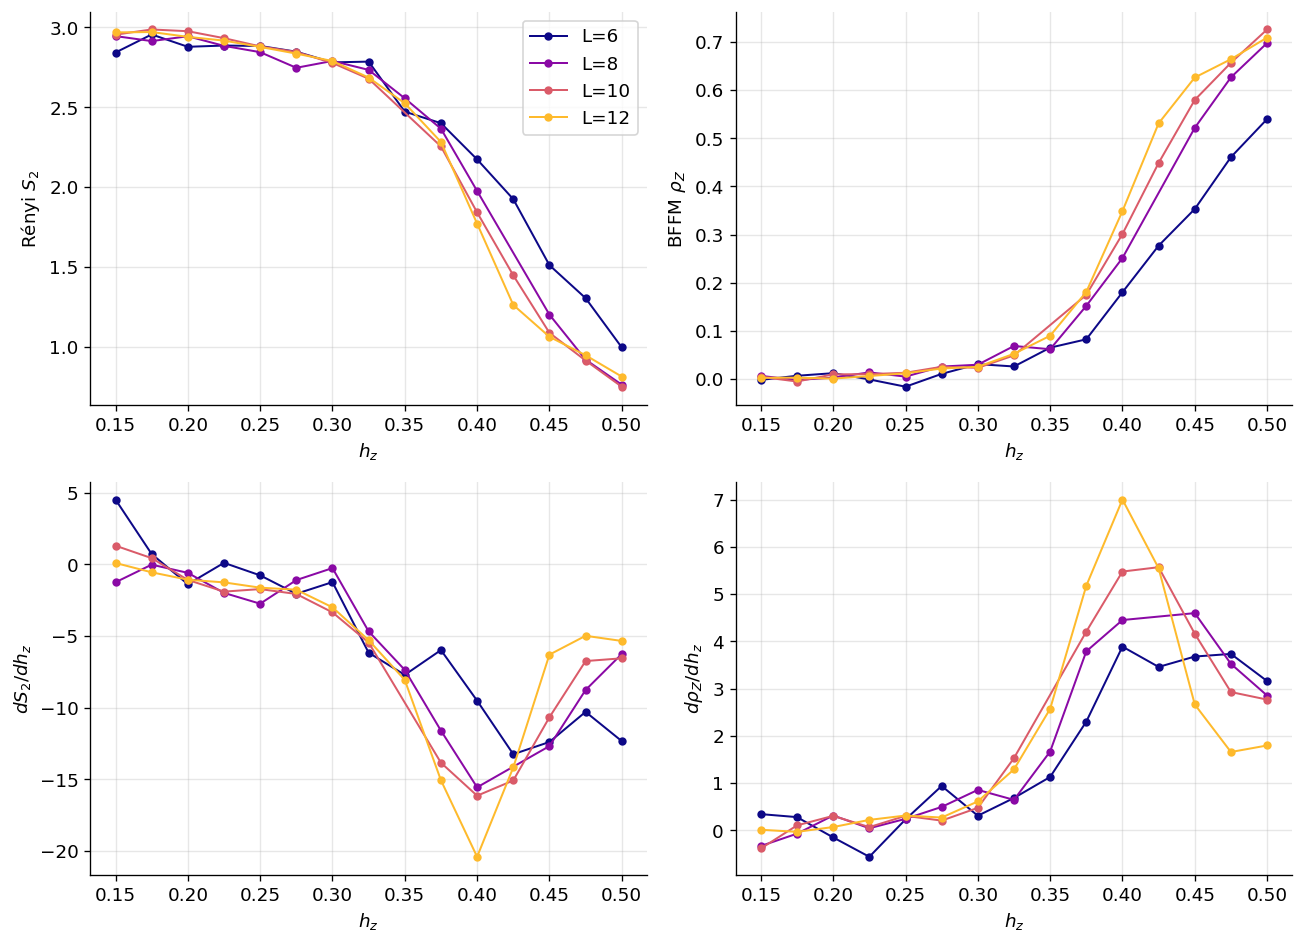

In [30]:
# S2 and BFFM (top) with their finite hz-derivatives (bottom) — 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_vs_hz(axes[0, 0], renyi2, "Rényi $S_2$")
plot_vs_hz(axes[0, 1], bffm_z, r"BFFM $\rho_Z$")
for ax, fn, ylab in [(axes[1, 0], renyi2, r"$dS_2/dh_z$"),
                     (axes[1, 1], bffm_z, r"$d\rho_Z/dh_z$")]:
    for L in Ls:
        hz, y = curve(L, fn)
        ax.plot(hz, np.gradient(y, hz), "o-", color=cols[L], ms=4, lw=1.2, label=f"L={L}")
    ax.set(xlabel="$h_z$", ylabel=ylab)
axes[0, 0].legend()
fig.tight_layout()
fig.savefig(FIG / "renyi_bffm_deriv.png", dpi=300, bbox_inches="tight")